In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [ ]:
seed = 1260

In [ ]:
X1, y1 = make_blobs(
    n_samples=200,
    centers=2,
    cluster_std=1.5,
    random_state=seed
)

y1[y1 == 0] = -1

In [ ]:
X2, y2 = make_circles(
    n_samples=200,
    noise=0.15,
    factor=0.5,
    random_state=seed
)

y2[y2 == 0] = -1

In [ ]:
X3, y3 = make_moons(
    n_samples=150,
    noise=0.15,
    random_state=seed
)

y3[y3 == 0] = -1

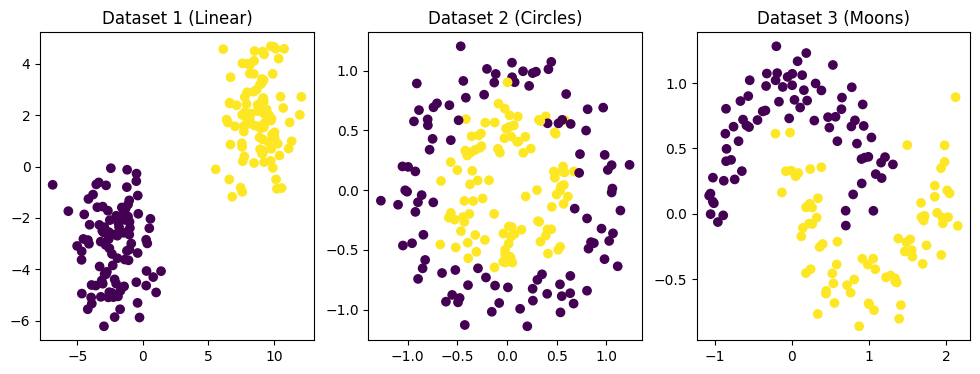

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(X1[:,0], X1[:,1], c=y1)
plt.title("Dataset 1 (Linear)")

plt.subplot(1,3,2)
plt.scatter(X2[:,0], X2[:,1], c=y2)
plt.title("Dataset 2 (Circles)")

plt.subplot(1,3,3)
plt.scatter(X3[:,0], X3[:,1], c=y3)
plt.title("Dataset 3 (Moons)")

plt.show()

In [ ]:
class LinearSVM:

    def __init__(self, lr=0.001, C=1, epochs=1000):

        self.lr = lr
        self.C = C
        self.epochs = epochs
        self.loss_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for epoch in range(self.epochs):

            loss = 0

            for i in range(n_samples):

                condition = y[i]*(np.dot(X[i],self.w) - self.b) >= 1

                if condition:
                    self.w -= self.lr*(2*self.w)

                else:
                    self.w -= self.lr*(2*self.w - self.C*y[i]*X[i])
                    self.b -= self.lr*self.C*y[i]

                hinge = max(0,1 - y[i]*(np.dot(self.w,X[i]) - self.b))
                loss += hinge

            total_loss = 0.5*np.dot(self.w,self.w) + self.C*loss
            self.loss_history.append(total_loss)

In [ ]:
model = LinearSVM()

model.fit(X1, y1)

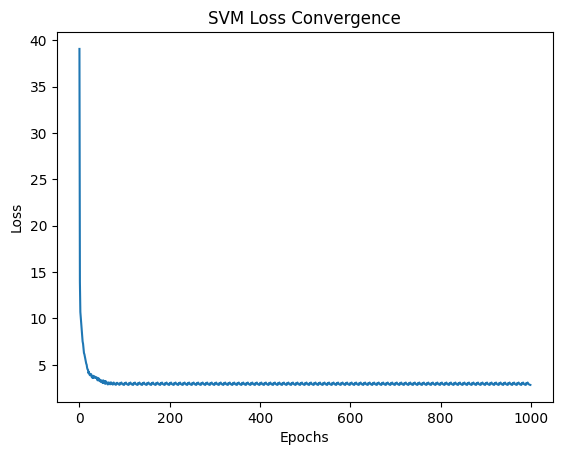

In [ ]:
plt.plot(model.loss_history)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("SVM Loss Convergence")

plt.show()

Observation:

The hinge loss decreases as the number of epochs increases, indicating that the optimization process is converging toward an optimal separating hyperplane.

In [ ]:
clf = SVC(kernel='linear', C=1.0)

clf.fit(X1, y1)

SVC(kernel='linear')

In [ ]:
w = clf.coef_[0]

b = clf.intercept_[0]

print("Weight vector:", w)
print("Bias:", b)

Weight vector: [0.34743799 0.13821312]
Bias: -0.9177132739794794


In [ ]:
margin = 2 / np.linalg.norm(w)

print("Margin width:", margin)

Margin width: 5.348740499880363


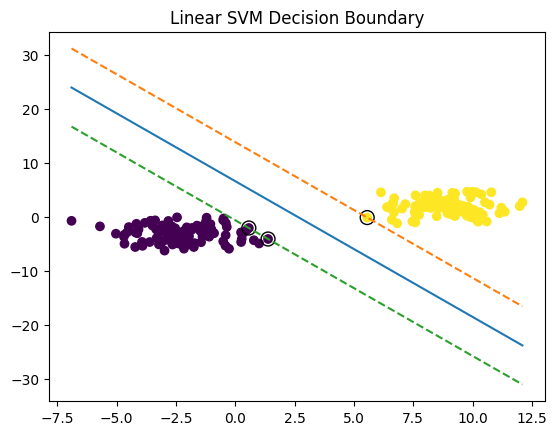

In [ ]:
x_vals = np.linspace(min(X1[:,0]), max(X1[:,0]), 100)

decision = -(w[0]*x_vals + b)/w[1]
margin_up = -(w[0]*x_vals + b - 1)/w[1]
margin_down = -(w[0]*x_vals + b + 1)/w[1]

plt.scatter(X1[:,0], X1[:,1], c=y1)

plt.plot(x_vals, decision)
plt.plot(x_vals, margin_up, '--')
plt.plot(x_vals, margin_down, '--')

plt.scatter(
    clf.support_vectors_[:,0],
    clf.support_vectors_[:,1],
    s=100,
    facecolors='none',
    edgecolors='k'
)

plt.title("Linear SVM Decision Boundary")

plt.show()

Observation:

The support vectors lie on the margin boundaries and determine the optimal separating hyperplane. The margin width is inversely proportional to the magnitude of the weight vector.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2,
    test_size=0.3,
    random_state=seed
)

In [ ]:
C_values = [0.1,1,10]
gamma_values = [0.01,0.1,1]

results = []

for C in C_values:
    for gamma in gamma_values:

        model = SVC(kernel='rbf', C=C, gamma=gamma)

        model.fit(X_train,y_train)

        train_acc = model.score(X_train,y_train)
        test_acc = model.score(X_test,y_test)

        results.append((C,gamma,train_acc,test_acc))

        print("C:",C," gamma:",gamma,
              " train:",train_acc,
              " test:",test_acc)

C: 0.1  gamma: 0.01  train: 0.5214285714285715  test: 0.45
C: 0.1  gamma: 0.1  train: 0.5214285714285715  test: 0.45
C: 0.1  gamma: 1  train: 0.9285714285714286  test: 0.9833333333333333
C: 1  gamma: 0.01  train: 0.5214285714285715  test: 0.45
C: 1  gamma: 0.1  train: 0.6  test: 0.5
C: 1  gamma: 1  train: 0.9357142857142857  test: 0.9666666666666667
C: 10  gamma: 0.01  train: 0.5214285714285715  test: 0.45
C: 10  gamma: 0.1  train: 0.9285714285714286  test: 0.95
C: 10  gamma: 1  train: 0.9428571428571428  test: 0.9833333333333333


Explanation:

High gamma values create very narrow influence regions around training samples.
This causes the model to fit the training data very closely, resulting in overfitting.
While training accuracy becomes very high, test accuracy often decreases.

In [ ]:
poly_model = SVC(kernel='poly', degree=3)

poly_model.fit(X_train,y_train)

print("Polynomial Train Accuracy:", poly_model.score(X_train,y_train))
print("Polynomial Test Accuracy:", poly_model.score(X_test,y_test))

Polynomial Train Accuracy: 0.5214285714285715
Polynomial Test Accuracy: 0.45


Conclusion:

The RBF kernel generally performs better for circular and moon-shaped datasets because it can model complex nonlinear boundaries.
Polynomial kernels create global decision boundaries and may not capture these shapes effectively.

Results Summary:

Task 2:
The hinge loss decreases with epochs indicating convergence.

Task 3:
The calculated margin width confirms that larger weight magnitudes produce smaller margins.

Task 4:
The RBF kernel performed better than the polynomial kernel for nonlinear datasets.
High gamma values resulted in overfitting.